# Sistema de Recomendación de Obras para el Carrito — NU★B Studio
### Filtrado colaborativo con SVD (no supervisado)

Este cuaderno construye el **tercer modelo de ML** del proyecto: recomendar obras en el
**carrito de compras** ("Completa tu colección"). Sigue la metodología **CRISP-DM**, igual
que los dos modelos anteriores.

**La idea — filtrado colaborativo:** en vez de mirar los *atributos* de las obras (como hace
el modelo de posts relacionados), este modelo aprende de las *coincidencias entre usuarios*:
"a quienes les interesaron estas obras, también les interesaron estas otras". Es el enfoque
que hicieron famoso Netflix y Amazon.

**Pipeline:** `Interacciones (favorito/carrito/compra) → Matriz usuario×obra → SVD → Recomendación`

**El trío de modelos del proyecto:**

| # | Modelo | Paradigma | Técnica |
|---|--------|-----------|---------|
| 1 | Clasificación de posts | Supervisado | Regresión Logística + TF-IDF |
| 2 | Posts relacionados | No supervisado (por contenido) | TF-IDF → SVD → K-Means |
| 3 | **Recomendador de obras** | **No supervisado (colaborativo)** | **Matriz de interacciones → SVD** |


# 1. Comprensión de los datos

## 1.1 Carga de datos

El dataset se construye uniendo **tres señales de interés** de un usuario por una obra:

| Señal | Tabla | Peso | Se lee como |
|-------|-------|------|-------------|
| Favorito | `favoritos` (activos) | 1 | "me gusta" |
| Carrito | `carritos` | 3 | "casi lo compro" |
| Compra | `ventas` (no canceladas) | 5 | "lo quise tanto que pagué" |

Nadie calificó nada con estrellas: el interés se **infiere de las acciones**. También cargamos
el catálogo de obras (categoría, técnica, precio...) para interpretar resultados y para el
respaldo por contenido del final.

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

BASE_DIR = os.getcwd()
CSV_INTER = os.path.join(BASE_DIR, "interacciones_dataset.csv")
CSV_OBRAS = os.path.join(BASE_DIR, "obras_features_dataset.csv")
ENV_PATH = os.path.abspath(os.path.join(BASE_DIR, "..", ".env"))

QUERY_INTER = '''
  SELECT id_usuario, id_obra, 1.0 AS peso, fecha_agregado AS fecha, 'favorito' AS tipo
    FROM favoritos WHERE activo
  UNION ALL
  SELECT id_usuario, id_obra, 3.0, fecha_agregado, 'carrito' FROM carritos
  UNION ALL
  SELECT id_cliente, id_obra, 5.0, fecha_venta, 'compra' FROM ventas WHERE NOT cancelado
'''
QUERY_OBRAS = '''
  SELECT o.id_obra, o.titulo, o.id_categoria, c.nombre AS categoria,
         o.id_tecnica, t.nombre AS tecnica, o.id_material,
         o.precio_base, o.dimensiones_alto, o.dimensiones_ancho
  FROM obras o
  LEFT JOIN categorias c ON c.id_categoria = o.id_categoria
  LEFT JOIN tecnicas   t ON t.id_tecnica   = o.id_tecnica
  WHERE o.activa AND NOT o.eliminada
'''
try:
    import psycopg2
    from dotenv import load_dotenv
    load_dotenv(ENV_PATH)
    conn = psycopg2.connect(host=os.environ["DB_HOST"], user=os.environ["DB_USER"],
        password=os.environ["DB_PASSWORD"], dbname=os.environ["DB_NAME"],
        port=os.environ.get("DB_PORT","5432"), sslmode="require")
    df_inter = pd.read_sql(QUERY_INTER, conn)
    df_obras = pd.read_sql(QUERY_OBRAS, conn)
    conn.close()
    df_inter.to_csv(CSV_INTER, index=False)   # respaldo para trabajar sin conexión
    df_obras.to_csv(CSV_OBRAS, index=False)
    print(f"Cargado EN VIVO desde Neon: {len(df_inter)} interacciones, {len(df_obras)} obras")
except Exception as e:
    print(f"Sin Neon ({type(e).__name__}); uso CSV de respaldo.")
    df_inter = pd.read_csv(CSV_INTER, parse_dates=["fecha"])
    df_obras = pd.read_csv(CSV_OBRAS)
    print(f"Cargado desde CSV: {len(df_inter)} interacciones, {len(df_obras)} obras")

print("\n>>> ASÍ SE VE EL DATASET CRUDO (una fila = una acción de un usuario sobre una obra):")
df_inter.head()

Cargado EN VIVO desde Neon: 17278 interacciones, 485 obras

>>> ASÍ SE VE EL DATASET CRUDO (una fila = una acción de un usuario sobre una obra):


,id_usuario,id_obra,peso,fecha,tipo
0,1337,1074,1.0,2026-07-16 02:26:26.477136,favorito
1,24,49,1.0,2026-04-10 13:23:11.071265,favorito
2,1337,1072,1.0,2026-07-16 02:26:26.477136,favorito
3,1337,1073,1.0,2026-07-16 02:26:26.477136,favorito
4,1337,1093,1.0,2026-07-16 02:26:26.477136,favorito


Y el catálogo de obras:

In [2]:
print(">>> CATÁLOGO DE OBRAS:")
df_obras.head()

>>> CATÁLOGO DE OBRAS:


,id_obra,titulo,id_categoria,categoria,id_tecnica,tecnica,id_material,precio_base,dimensiones_alto,dimensiones_ancho
0,1340,Río Moctezuma al Amanecer,1,Fotografía,3.0,HDR,1,1050.0,21.94,18.73
1,1438,Papel Amate Pintado,4,Artesanía,58.0,Pintado en amate,18,3450.0,43.03,44.18
2,50,Expiatorio en Guadalajara,1,Fotografía,1.0,Fotografía digital,1,2700.0,80.30,61.07
3,1345,Tejedora de Xilitla,1,Fotografía,2.0,Fotografía analógica,1,3350.0,28.72,21.51
4,1364,Milpa Sagrada,2,Pintura,9.0,Temple,11,8800.0,60.00,45.00


## 1.2 Descripción de atributos

**Interacciones:** `id_usuario` e `id_obra` (quién con qué), `peso` (fuerza de la señal),
`fecha` (cuándo — la usaremos para el examen del modelo) y `tipo` (de qué tabla vino).

**Obras:** categoría, técnica y material (categóricas); precio y dimensiones (numéricas).

In [3]:
print("Interacciones:", df_inter.shape)
df_inter.info()
print("\nObras:", df_obras.shape)
df_obras.info()

Interacciones: (17278, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17278 entries, 0 to 17277
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id_usuario  17278 non-null  int64         
 1   id_obra     17278 non-null  int64         
 2   peso        17278 non-null  float64       
 3   fecha       17278 non-null  datetime64[ns]
 4   tipo        17278 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 675.1+ KB

Obras: (485, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 485 entries, 0 to 484
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_obra            485 non-null    int64  
 1   titulo             485 non-null    object 
 2   id_categoria       485 non-null    int64  
 3   categoria          485 non-null    object 
 4   id_tecnica         482 non-null

## 1.3 Calidad de los datos

In [4]:
print("Nulos en interacciones:")
print(df_inter.isnull().sum())
print("\nNulos en obras:")
print(df_obras.isnull().sum())

dup = df_inter.duplicated(subset=["id_usuario","id_obra","tipo"]).sum()
print(f"\nEventos duplicados exactos (usuario+obra+tipo): {dup}")

huerfanas = (~df_inter.id_obra.isin(df_obras.id_obra)).sum()
print(f"Interacciones hacia obras fuera del catálogo activo: {huerfanas}")

compras = df_inter[df_inter.tipo=="compra"]
con_fav = compras.merge(df_inter[df_inter.tipo=="favorito"], on=["id_usuario","id_obra"], how="left", suffixes=("","_f"))
print(f"\nCompras que tuvieron favorito previo: {con_fav.peso_f.notna().mean():.1%}  (el embudo favorito→compra se cumple)")

Nulos en interacciones:
id_usuario    0
id_obra       0
peso          0
fecha         0
tipo          0
dtype: int64

Nulos en obras:
id_obra              0
titulo               0
id_categoria         0
categoria            0
id_tecnica           3
tecnica              3
id_material          0
precio_base          0
dimensiones_alto     0
dimensiones_ancho    0
dtype: int64

Eventos duplicados exactos (usuario+obra+tipo): 59
Interacciones hacia obras fuera del catálogo activo: 2

Compras que tuvieron favorito previo: 97.3%  (el embudo favorito→compra se cumple)


## 1.4 Análisis Exploratorio (EDA)

Tres preguntas clave para un recomendador:
1. ¿Cómo se reparten las señales? (deberían dominar los favoritos)
2. ¿Cuánta actividad tiene cada usuario? (si es muy poca, no hay de dónde aprender)
3. ¿Cuántas obras se quedan sin interacciones? (esas serán el reto del final)

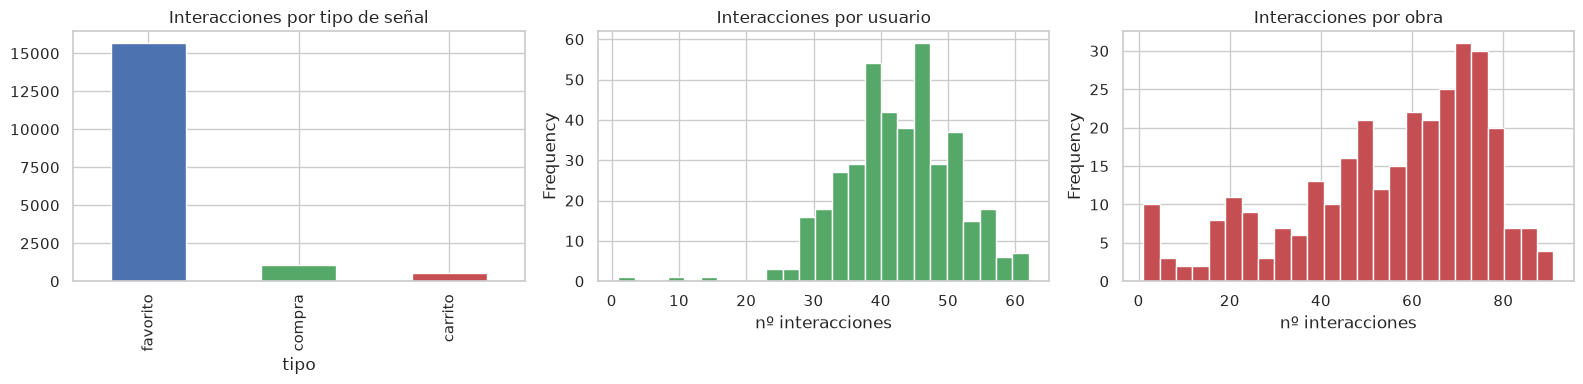

Usuarios: 404 | interacciones por usuario: media 42.8, mediana 43
Obras del catálogo SIN ninguna interacción: 171 de 485


In [5]:
fig, ax = plt.subplots(1, 3, figsize=(16,4))
df_inter.tipo.value_counts().plot.bar(ax=ax[0], color=["#4C72B0","#55A868","#C44E52"])
ax[0].set_title("Interacciones por tipo de señal")
df_inter.groupby("id_usuario").size().plot.hist(bins=25, ax=ax[1], color="#55A868")
ax[1].set_title("Interacciones por usuario"); ax[1].set_xlabel("nº interacciones")
df_inter.groupby("id_obra").size().plot.hist(bins=25, ax=ax[2], color="#C44E52")
ax[2].set_title("Interacciones por obra"); ax[2].set_xlabel("nº interacciones")
plt.tight_layout(); plt.show()

por_usuario = df_inter.groupby("id_usuario").size()
print(f"Usuarios: {df_inter.id_usuario.nunique()} | interacciones por usuario: media {por_usuario.mean():.1f}, mediana {por_usuario.median():.0f}")
frias = df_obras[~df_obras.id_obra.isin(df_inter.id_obra)]
print(f"Obras del catálogo SIN ninguna interacción: {len(frias)} de {len(df_obras)}")

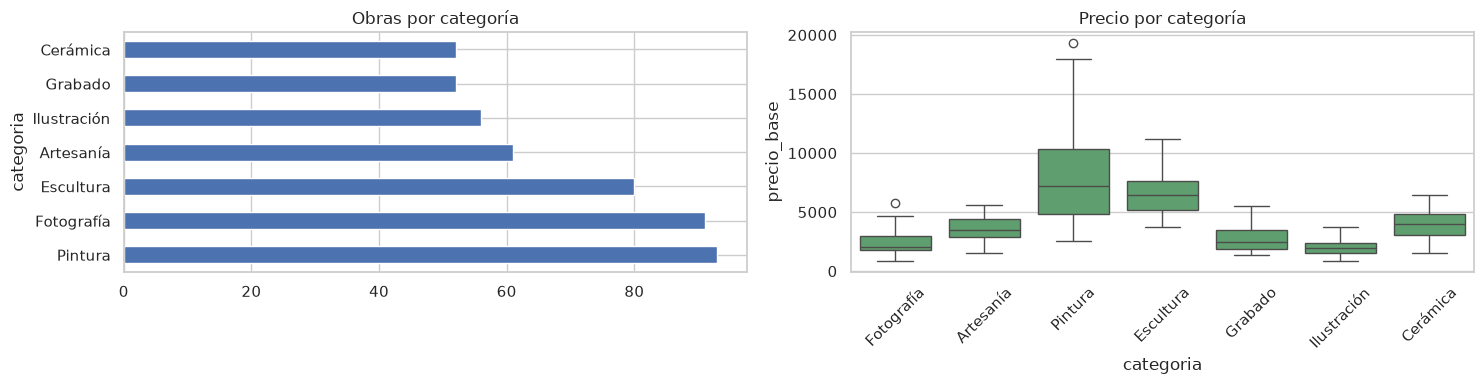

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15,4))
df_obras.categoria.value_counts().plot.barh(ax=ax[0], color="#4C72B0")
ax[0].set_title("Obras por categoría")
sns.boxplot(data=df_obras, x="categoria", y="precio_base", ax=ax[1], color="#55A868")
ax[1].set_title("Precio por categoría"); ax[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

**Nota sobre el origen de los datos:** casi todas las interacciones vienen de los **400
clientes seed** (generados con 6 arquetipos de gusto por categoría). Es comportamiento simulado
pero coherente — respeta el embudo favorito→carrito→compra y gustos estables — diseñado para
poder entrenar este tipo de modelo. Lo retomamos en las conclusiones.

# 2. Preparación de los datos

## 2.1 De eventos a pares usuario–obra

Un usuario puede tener varios eventos con la misma obra (favorito, luego carrito, luego compra).
Al modelo le importa **la relación**, así que dejamos **un registro por par (usuario, obra)**
con la señal más fuerte que alcanzó.

In [7]:
pares = (df_inter
         .groupby(["id_usuario","id_obra"])
         .agg(peso=("peso","max"), fecha=("fecha","max"))
         .reset_index())
print(f"De {len(df_inter)} eventos → {len(pares)} pares usuario-obra únicos")
print(">>> DATASET DEDUPLICADO:")
pares.head()

De 17278 eventos → 15683 pares usuario-obra únicos
>>> DATASET DEDUPLICADO:


,id_usuario,id_obra,peso,fecha
0,23,36,3.0,2026-04-08 21:59:23.854812
1,24,39,5.0,2026-06-03 19:26:13.656535
2,24,44,5.0,2026-07-08 18:55:43.581776
3,24,45,5.0,2026-07-07 19:35:07.889447
4,24,48,5.0,2026-07-08 15:05:49.920905


# 3. Selección y transformación de características

La transformación clave: la tabla "larga" de pares se **pivotea** a una **matriz usuario × obra**.
Cada obra se vuelve una columna; cada celda dice si ese usuario interactuó con esa obra.

Es el mismo patrón del modelo 2: allá la matriz era *posts × palabras* (TF-IDF); aquí es
*usuarios × obras*. **Los ceros no significan "no le gusta" sino "no sabemos"** — y rellenar
esos huecos es justamente la tarea del modelo.

## 3.1 El pivote: de tabla larga a matriz usuario×obra

In [8]:
matriz = pares.pivot_table(index="id_usuario", columns="id_obra",
                           values="peso", aggfunc="max", fill_value=0)
usuarios = matriz.index.to_numpy()     # id de usuario de cada fila
obras_m  = matriz.columns.to_numpy()   # id de obra de cada columna
print(f">>> MATRIZ USUARIO×OBRA: {matriz.shape[0]} usuarios x {matriz.shape[1]} obras")
print(f"    Celdas con interacción: {(matriz.values>0).mean():.1%} (el resto son los huecos a rellenar)")
print("\n>>> PEDACITO REAL DE LA MATRIZ (6 usuarios x 10 obras):")
matriz.iloc[10:16, 30:40]

>>> MATRIZ USUARIO×OBRA: 404 usuarios x 315 obras
    Celdas con interacción: 12.3% (el resto son los huecos a rellenar)

>>> PEDACITO REAL DE LA MATRIZ (6 usuarios x 10 obras):


id_obra,973,974,975,976,977,978,979,980,981,982
id_usuario,,,,,,,,,,
1343,5.0,1.0,1.0,0.0,0.0,5.0,0.0,1.0,1.0,0.0
1344,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0
1345,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1346,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1347,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1348,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3.2 Vectores de contenido de las obras

Para las obras sin interacciones prepararemos un respaldo que compara **atributos** (§6).
Codificamos: categóricas con *one-hot* (una columna por categoría/técnica/material, como en
clase) y numéricas estandarizadas para que el precio no domine por tener números grandes.

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

obras_idx = df_obras.set_index("id_obra")
X_cat = pd.get_dummies(obras_idx[["id_categoria","id_tecnica","id_material"]]
                       .astype("Int64").astype(str), prefix=["cat","tec","mat"])
num = obras_idx[["precio_base","dimensiones_alto","dimensiones_ancho"]].astype(float)
num = num.fillna(num.median())
X_num = pd.DataFrame(StandardScaler().fit_transform(num), index=obras_idx.index, columns=num.columns)
X_contenido = pd.concat([X_cat, X_num], axis=1).astype(float)
S_contenido = pd.DataFrame(cosine_similarity(X_contenido),
                           index=X_contenido.index, columns=X_contenido.index)
print(f">>> CADA OBRA DESCRITA POR SUS ATRIBUTOS: {X_contenido.shape[0]} obras x {X_contenido.shape[1]} columnas")
X_contenido.head()

>>> CADA OBRA DESCRITA POR SUS ATRIBUTOS: 485 obras x 65 columnas


,cat_1,cat_2,cat_3,cat_4,cat_5,cat_6,cat_7,tec_1,tec_10,tec_11,...,mat_3,mat_4,mat_5,mat_6,mat_7,mat_8,mat_9,precio_base,dimensiones_alto,dimensiones_ancho
id_obra,,,,,,,,,,,,,,,,,,,,,
1340,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.111593,-0.850108,-0.853581
1438,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.343749,-0.409695,-0.140408
50,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.583700,0.368599,0.332892
1345,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.375742,-0.708524,-0.775679
1364,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.367904,-0.055317,-0.117430


## 3.3 El examen: partición train / test

Para calificar al modelo sin hacernos trampa, a cada comprador le **escondemos su compra más
reciente** (y también el favorito/carrito que le puso a esa misma obra — si lo dejáramos, el
modelo "vería" la respuesta). El modelo estudia con lo demás y en el examen le preguntamos:
*¿qué recomendarías?* Si la compra escondida sale en su top-10, acertó.

In [10]:
compras_ord = df_inter[df_inter.tipo=="compra"].sort_values("fecha")
ultima = compras_ord.groupby("id_usuario").tail(1)
n_compras = compras_ord.groupby("id_usuario").size()
test = ultima[ultima.id_usuario.map(n_compras) >= 2][["id_usuario","id_obra"]].reset_index(drop=True)
test_keys = set(zip(test.id_usuario, test.id_obra))

pares_train = pares[~pares.apply(lambda r: (r.id_usuario, r.id_obra) in test_keys, axis=1)]
M_train = (pares_train.pivot_table(index="id_usuario", columns="id_obra",
                                   values="peso", aggfunc="max", fill_value=0)
           .reindex(index=usuarios, columns=obras_m, fill_value=0))
Mb_train = (M_train > 0).astype(float)   # versión binaria: ¿interactuó o no?

print(f"Usuarios de examen (compra escondida): {len(test)}")
print(f"Pares para entrenar: {len(pares_train)}")

Usuarios de examen (compra escondida): 270
Pares para entrenar: 15413


# 4. Modelado — comparación de 3 candidatos

Comparamos con la misma vara tres enfoques, del más simple al más completo:

| Candidato | Idea |
|-----------|------|
| Popularidad (baseline) | recomendar lo más popular a todos por igual |
| KNN por contenido | obras con atributos parecidos a las de tu historial |
| **SVD colaborativo** | factores latentes de gusto aprendidos del comportamiento |

**La métrica — HitRate@10:** porcentaje de usuarios cuya compra escondida apareció en su
top-10 recomendado. Para dimensionar: con 315 obras, **adivinar al azar da ≈ 3%**.

## 4.1 La función que califica a cada candidato

In [11]:
idx_obra = {o: i for i, o in enumerate(obras_m)}      # id_obra -> columna
idx_usuario = {u: i for i, u in enumerate(usuarios)}  # id_usuario -> fila
Mb_np = Mb_train.to_numpy()
vistos = {u: np.flatnonzero(Mb_np[idx_usuario[u]]) for u in test.id_usuario}

def evaluar(nombre, score_fn, K=10):
    """score_fn(fila_usuario) -> puntuación de las 315 obras. Mide HitRate@K."""
    hits, n = 0, 0
    for _, row in test.iterrows():
        if row.id_obra not in idx_obra: continue
        u = idx_usuario[row.id_usuario]
        scores = np.asarray(score_fn(u), dtype=float)
        scores[vistos[row.id_usuario]] = -np.inf     # no recomendar lo ya interactuado
        hits += idx_obra[row.id_obra] in np.argsort(-scores)[:K]
        n += 1
    hr = hits / n
    print(f"{nombre:<24} HitRate@{K}: {hr:.3f}   (n={n})")
    return hr

resultados = {}

## 4.2 Candidato 1 — Popularidad (baseline)

El punto de referencia obligado: a **todos** les recomendamos las obras con más interacciones.
Un modelo que no supere esto no está aprendiendo gustos personales.

In [12]:
popularidad = Mb_np.sum(axis=0)
resultados["Popularidad"] = evaluar("Popularidad (baseline)", lambda u: popularidad.copy())

Popularidad (baseline)   HitRate@10: 0.044   (n=270)


## 4.3 Candidato 2 — KNN por contenido

Como el KNN de clase, pero para rankear: puntuamos cada obra por su **similitud promedio de
atributos** contra las obras del historial del usuario. Solo usa categoría/técnica/material/
precio — no sabe nada de lo que hacen otros usuarios.

In [13]:
S_cont_np = S_contenido.reindex(index=obras_m, columns=obras_m).to_numpy()

def score_contenido(u):
    historial = np.flatnonzero(Mb_np[u])
    return S_cont_np[:, historial].mean(axis=1)

resultados["KNN contenido"] = evaluar("KNN contenido", score_contenido)

KNN contenido            HitRate@10: 0.152   (n=270)


## 4.4 Candidato 3 — SVD colaborativo

El mismo `TruncatedSVD` que usaste en el modelo 2, pero con otro papel: allá comprimía la matriz
de palabras antes del K-Means; **aquí la compresión ES el modelo**. Descompone la matriz en:

- `U` (usuarios × k): cada usuario resumido en k números — su **vector de gusto**
- `V` (k × obras): cada obra resumida en k números — su **perfil**

Al multiplicar `U × V` se reconstruye la matriz **con los huecos rellenados**: cada cero se
sustituye por la mejor estimación de interés. Esas estimaciones, ordenadas, son la recomendación.

**Primero decidimos con qué matriz alimentarlo** (¿pesos 1/3/5 o binaria?):

In [14]:
from sklearn.decomposition import TruncatedSVD

def hitrate_svd(Mx, k):
    svd_k = TruncatedSVD(n_components=k, random_state=RANDOM_STATE)
    U = svd_k.fit_transform(Mx); V = svd_k.components_
    hits, n = 0, 0
    for _, row in test.iterrows():
        if row.id_obra not in idx_obra: continue
        u = idx_usuario[row.id_usuario]
        s = U[u] @ V
        s[vistos[row.id_usuario]] = -np.inf
        hits += idx_obra[row.id_obra] in np.argsort(-s)[:10]; n += 1
    return hits/n

M_np = M_train.to_numpy()
print(f"SVD (k=10) con matriz ponderada 1/3/5: {hitrate_svd(M_np, 10):.3f}")
print(f"SVD (k=10) con matriz binaria:        {hitrate_svd(Mb_np, 10):.3f}")
print("\n>>> La binaria rinde igual o mejor: con ~40 obras por usuario, QUÉ obras tocó")
print("    ya dice todo sobre su gusto; el cuánto aporta poco. Nos quedamos con la binaria.")

SVD (k=10) con matriz ponderada 1/3/5: 0.093


SVD (k=10) con matriz binaria:        0.144

>>> La binaria rinde igual o mejor: con ~40 obras por usuario, QUÉ obras tocó
    ya dice todo sobre su gusto; el cuánto aporta poco. Nos quedamos con la binaria.


**Ahora elegimos k (el número de factores)** con una curva de validación — el equivalente
del *método del codo* que usaste para elegir el k del K-Means:
- k muy chico → *subajuste*: no le caben los patrones de gusto
- k muy grande → *sobreajuste*: memoriza ruido y empeora

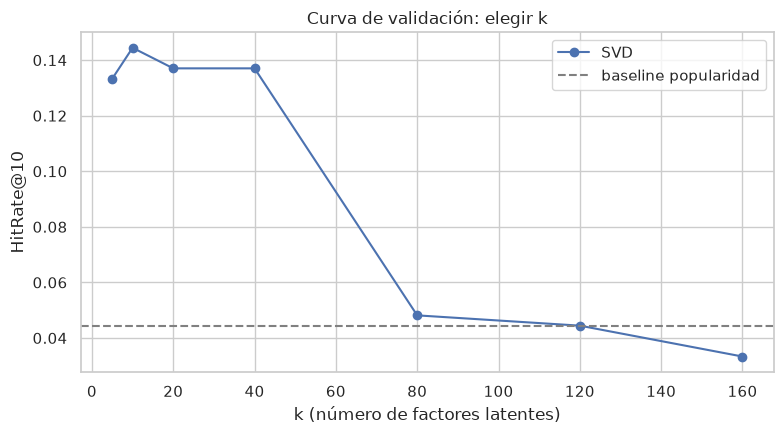

>>> Mejor k: 10 (HitRate@10 = 0.144)
>>> Observa el sobreajuste: con k grande el modelo EMPEORA — memoriza en vez de aprender.


In [15]:
ks = [5, 10, 20, 40, 80, 120, 160]
curva = [hitrate_svd(Mb_np, k) for k in ks]

plt.figure(figsize=(8,4.5))
plt.plot(ks, curva, "o-", color="#4C72B0", label="SVD")
plt.axhline(resultados["Popularidad"], ls="--", color="gray", label="baseline popularidad")
plt.xlabel("k (número de factores latentes)"); plt.ylabel("HitRate@10")
plt.title("Curva de validación: elegir k")
plt.legend(); plt.tight_layout(); plt.show()

K_OPTIMO = ks[int(np.argmax(curva))]
print(f">>> Mejor k: {K_OPTIMO} (HitRate@10 = {max(curva):.3f})")
print(">>> Observa el sobreajuste: con k grande el modelo EMPEORA — memoriza en vez de aprender.")

## 4.5 Comparación final y elección

SVD k=10                 HitRate@10: 0.144   (n=270)


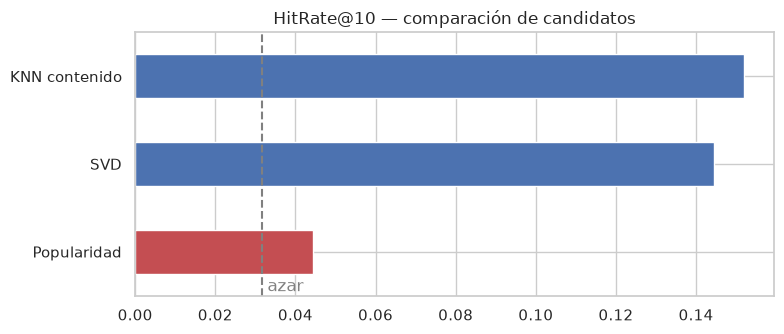

Popularidad      0.044
SVD              0.144
KNN contenido    0.152
dtype: float64

In [16]:
svd_model = TruncatedSVD(n_components=K_OPTIMO, random_state=RANDOM_STATE)
U_train = svd_model.fit_transform(Mb_np); V_train = svd_model.components_
resultados["SVD"] = evaluar(f"SVD k={K_OPTIMO}", lambda u: U_train[u] @ V_train)

comp = pd.Series(resultados).sort_values()
fig, ax = plt.subplots(figsize=(8,3.5))
comp.plot.barh(ax=ax, color=["#C44E52" if i=="Popularidad" else "#4C72B0" for i in comp.index])
ax.axvline(10/len(obras_m), ls="--", color="gray")
ax.text(10/len(obras_m), -0.45, " azar", color="gray")
ax.set_title("HitRate@10 — comparación de candidatos")
plt.tight_layout(); plt.show()
comp.round(3)

**Decisión, con números:** KNN contenido y SVD quedan casi empatados, ambos ~3-4x arriba
del baseline. Elegimos el **SVD** como modelo del sistema:

1. **Es un modelo que se entrena** — aprende parámetros, tiene un hiperparámetro (k) elegido
   con curva de validación y muestra sobreajuste. El KNN no entrena nada: compara atributos fijos.
2. **Ojo con el KNN:** luce bien en parte porque los clientes seed se generaron con gustos
   *por categoría* — exactamente lo que sus atributos codifican. Con usuarios reales (gustos más
   matizados) lo esperable es que el colaborativo domine, como reporta la literatura.
3. **El SVD mejora solo:** cada interacción real nueva lo enriquece al reentrenar; el KNN queda
   limitado para siempre a sus atributos fijos.

El KNN no se tira a la basura: será el **respaldo** para las obras sin interacciones (§6).

# 5. Evaluación del modelo elegido

## 5.1 ¿Y si la lista fuera más corta o más larga?

Medimos el acierto para varios tamaños de lista (K) y comparamos contra el baseline.

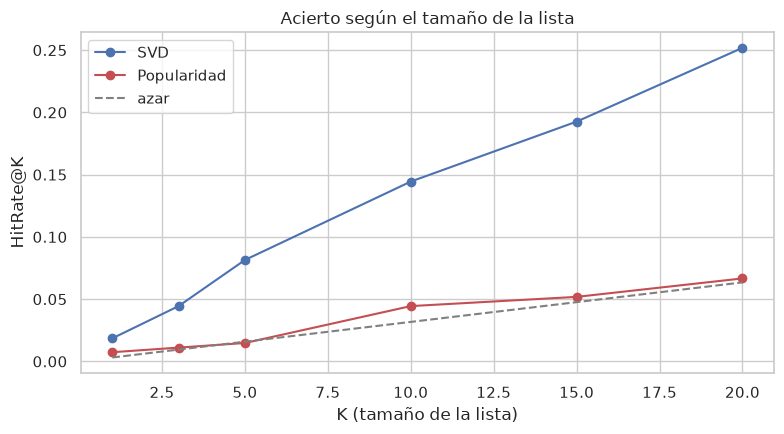

  HitRate@1 : 0.019
  HitRate@3 : 0.044
  HitRate@5 : 0.081
  HitRate@10: 0.144
  HitRate@15: 0.193
  HitRate@20: 0.252


In [17]:
def hitrate_curva(score_fn, Ks=(1,3,5,10,15,20)):
    res = []
    for K in Ks:
        hits, n = 0, 0
        for _, row in test.iterrows():
            if row.id_obra not in idx_obra: continue
            u = idx_usuario[row.id_usuario]
            s = np.asarray(score_fn(u), dtype=float)
            s[vistos[row.id_usuario]] = -np.inf
            hits += idx_obra[row.id_obra] in np.argsort(-s)[:K]; n += 1
        res.append(hits/n)
    return list(Ks), res

Ks, hr_svd = hitrate_curva(lambda u: U_train[u] @ V_train)
_,  hr_pop = hitrate_curva(lambda u: popularidad.copy())
plt.figure(figsize=(8,4.5))
plt.plot(Ks, hr_svd, "o-", label="SVD", color="#4C72B0")
plt.plot(Ks, hr_pop, "o-", label="Popularidad", color="#C44E52")
plt.plot(Ks, [k/len(obras_m) for k in Ks], "--", color="gray", label="azar")
plt.xlabel("K (tamaño de la lista)"); plt.ylabel("HitRate@K")
plt.title("Acierto según el tamaño de la lista"); plt.legend(); plt.tight_layout(); plt.show()
for K, h in zip(Ks, hr_svd): print(f"  HitRate@{K:<2}: {h:.3f}")

## 5.2 ¿Acierta el *gusto* aunque no la obra exacta?

Adivinar la obra exacta entre 315 es la vara más dura (dentro de un mismo gusto muchas obras
son intercambiables). Medida más realista: ¿el top-10 contiene obras de la **categoría** de la
compra escondida?

In [18]:
cat_de = obras_idx.categoria.to_dict()
ok, n = 0, 0
for _, row in test.iterrows():
    if row.id_obra not in idx_obra: continue
    u = idx_usuario[row.id_usuario]
    s = U_train[u] @ V_train
    s[vistos[row.id_usuario]] = -np.inf
    top10 = [obras_m[i] for i in np.argsort(-s)[:10]]
    ok += cat_de.get(row.id_obra) in {cat_de.get(o) for o in top10}; n += 1
print(f"La categoría de la compra real aparece en el top-10: {ok/n:.1%} de los casos")
print("(el modelo captura el GUSTO del cliente aunque la obra exacta sea difícil)")

La categoría de la compra real aparece en el top-10: 64.8% de los casos
(el modelo captura el GUSTO del cliente aunque la obra exacta sea difícil)


## 5.3 ¿Qué aprendió? El espacio latente en 2D

Dibujamos las obras con sus 2 primeros factores latentes, coloreadas por categoría — igual que
la gráfica 2D de los grupos del modelo 2. Importante: **el modelo nunca vio la categoría**.
Si aun así las obras de la misma categoría quedan juntas, es la prueba visual de que descubrió
la estructura de gustos por sí solo.

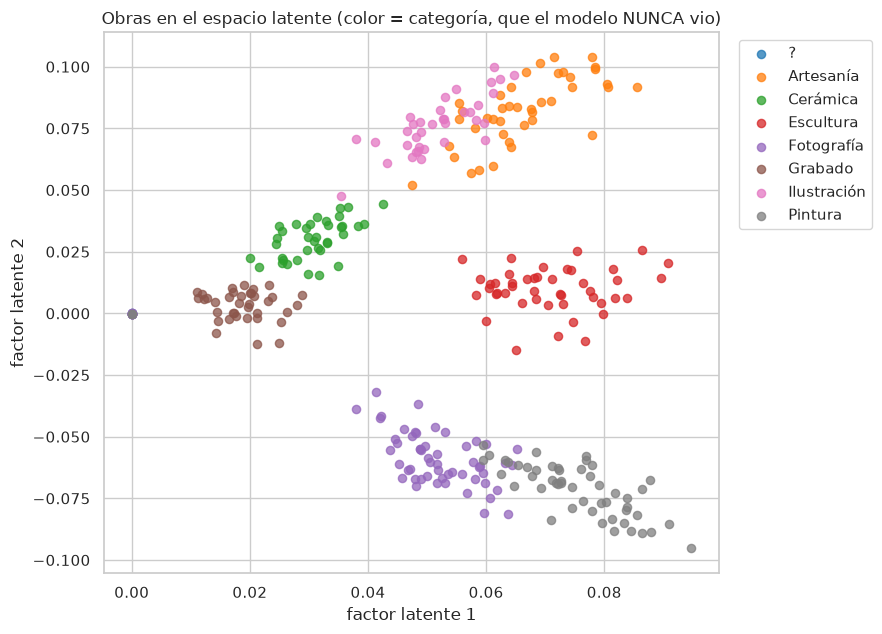

In [19]:
V2 = V_train[:2]
cats = pd.Series([cat_de.get(o, "?") for o in obras_m])
plt.figure(figsize=(9,6.5))
for c, color in zip(sorted(cats.unique()), sns.color_palette("tab10", cats.nunique())):
    m = (cats == c).to_numpy()
    plt.scatter(V2[0][m], V2[1][m], label=c, s=35, alpha=0.75, color=color)
plt.xlabel("factor latente 1"); plt.ylabel("factor latente 2")
plt.title("Obras en el espacio latente (color = categoría, que el modelo NUNCA vio)")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left"); plt.tight_layout(); plt.show()

# 6. Uso del modelo — recomendaciones para el carrito

Ya validado, **reentrenamos con TODOS los datos** (en producción no se desperdicia el examen).

**El modelo es el SVD.** Pero al desplegarlo hay dos casos donde no puede responder — un usuario
que no está en la matriz, o una obra que nadie ha tocado — así que el sistema lleva **dos
respaldos sin aprendizaje** (igual que el modelo 2 lleva su tabla precalculada: ingeniería
alrededor del modelo, no modelos extra):

1. **SVD** — usuario con historial y/o carrito con obras conocidas (el caso normal).
2. **Respaldo por contenido** — solo carrito con obras nuevas: similitud de atributos (§3.2).
3. **Respaldo de popularidad** — usuario nuevo con carrito vacío: lo más querido de la galería.

In [20]:
Mb_full = (matriz > 0).astype(float)
Mb_full_np = Mb_full.to_numpy()
svd_final = TruncatedSVD(n_components=K_OPTIMO, random_state=RANDOM_STATE)
U_full = svd_final.fit_transform(Mb_full_np)
V_full = svd_final.components_
populares_global = Mb_full_np.sum(axis=0)
idx_usuario_full = {u: i for i, u in enumerate(matriz.index)}
print(f"Modelo final: SVD k={K_OPTIMO} entrenado con la matriz completa {Mb_full.shape}")

Modelo final: SVD k=10 entrenado con la matriz completa (404, 315)


La función que usará la app (la misma que vivirá en el microservicio):

In [21]:
def top_legible(scores_por_obra, excluir, n):
    """Recibe una Serie id_obra->score, quita 'excluir' y arma el top-n legible."""
    s = scores_por_obra.drop(index=[o for o in excluir if o in scores_por_obra.index])
    top = s.sort_values(ascending=False).head(n)
    rec = obras_idx.loc[top.index, ["titulo","categoria","tecnica","precio_base"]].copy()
    rec["score"] = np.round(top.values, 3)
    rec.index.name = "id_obra"
    return rec.reset_index()

def recomendar_carrito(id_usuario=None, ids_carrito=(), n=6):
    ids_carrito = [o for o in ids_carrito if o in S_contenido.index]
    conocidas = [o for o in ids_carrito if o in idx_obra]   # obras del carrito que el SVD conoce
    u = idx_usuario_full.get(id_usuario)
    ya_visto = [obras_m[i] for i in np.flatnonzero(Mb_full_np[u])] if u is not None else []

    # 1) SVD: armamos la "fila" del usuario (historial + carrito pesando doble) y puntuamos
    fila = Mb_full_np[u].copy() if u is not None else np.zeros(len(obras_m))
    for o in conocidas:
        fila[idx_obra[o]] += 2.0
    if fila.sum() > 0:
        gusto = svd_final.transform(fila.reshape(1,-1))[0]      # vector latente del contexto
        scores = pd.Series(gusto @ V_full, index=obras_m)       # la reconstrucción rellena los huecos
        return top_legible(scores, ya_visto + ids_carrito, n), "svd"

    # 2) Respaldo contenido: solo hay obras desconocidas en el carrito
    if ids_carrito:
        scores = S_contenido[ids_carrito].mean(axis=1)
        return top_legible(scores, ids_carrito, n), "contenido"

    # 3) Respaldo popularidad: no hay absolutamente nada
    scores = pd.Series(populares_global, index=obras_m)
    return top_legible(scores, [], n), "popularidad"

print("Función recomendar_carrito() lista.")

Función recomendar_carrito() lista.


## 6.1 Ejemplo real: cliente con historial y carrito activo

In [22]:
carritos_reales = df_inter[df_inter.tipo=="carrito"]
uid = carritos_reales.id_usuario.value_counts().index[0]
carrito_de_u = carritos_reales[carritos_reales.id_usuario==uid].id_obra.tolist()

print(f"Cliente {uid} — historial por categoría:")
print(obras_idx.reindex(df_inter[df_inter.id_usuario==uid].id_obra).categoria.value_counts().to_string())
print("\nTrae en el carrito:")
print(obras_idx.reindex(carrito_de_u)[["titulo","categoria","precio_base"]].to_string())

rec, nivel = recomendar_carrito(uid, carrito_de_u)
print(f"\n>>> RECOMENDACIONES (respondió: {nivel}):")
rec

Cliente 30 — historial por categoría:
categoria
Fotografía    14
Pintura        1

Trae en el carrito:
                                        titulo   categoria  precio_base
id_obra                                                                
55                                     libro 2     Pintura       9550.0
41                      Amigos tomando el sol.  Fotografía       3400.0
43                                 Sierra Alta  Fotografía       2000.0
44       De camino a mi departamento en Chapul  Fotografía       1600.0
49                           Portal de Colores  Fotografía       4650.0
51                           Espíritu Navideño  Fotografía       2150.0
48                           Capital de Pueblo  Fotografía       4500.0
42                            Valle de Sombras  Fotografía       4400.0
50                   Expiatorio en Guadalajara  Fotografía       2700.0
47                                      Tlahui  Fotografía       3950.0
1215                       Niebla

,id_obra,titulo,categoria,tecnica,precio_base,score
0,1210,Serranía en Lluvia 2,Fotografía,Fotografía analógica,2000.0,0.108
1,1195,Ceiba Sagrada 11,Fotografía,Fotografía macro,1200.0,0.103
2,1131,Ceiba Sagrada 7,Fotografía,Fotografía analógica,1250.0,0.098
3,1219,Ceiba Sagrada 11,Fotografía,Fotografía digital,2100.0,0.096
4,978,Amanecer en la Huasteca 10,Pintura,Acrílico,9350.0,0.096
5,967,Niebla en Molango 11,Fotografía,HDR,2950.0,0.092


## 6.2 Ejemplo: obra sin interacciones en el carrito

Un usuario sin historial mete al carrito una obra que nadie ha tocado. El SVD no sabe nada de
ella → responde el respaldo por contenido.

In [23]:
obra_fria = frias.id_obra.iloc[0]
print("Obra en el carrito (sin interacciones):")
print(obras_idx.loc[[obra_fria], ["titulo","categoria","tecnica","precio_base"]].to_string())
rec, nivel = recomendar_carrito(id_usuario=None, ids_carrito=[obra_fria])
print(f"\n>>> RECOMENDACIONES (respondió: {nivel}):")
rec

Obra en el carrito (sin interacciones):
                            titulo   categoria tecnica  precio_base
id_obra                                                            
1340     Río Moctezuma al Amanecer  Fotografía     HDR       1050.0

>>> RECOMENDACIONES (respondió: contenido):


,id_obra,titulo,categoria,tecnica,precio_base,score
0,1128,Cascada de Tamul 4,Fotografía,HDR,950.0,0.997
1,967,Niebla en Molango 11,Fotografía,HDR,2950.0,0.968
2,1351,Cascada Tamul,Fotografía,HDR,1300.0,0.964
3,1066,Serranía en Lluvia 2,Fotografía,HDR,2000.0,0.946
4,1041,Montes Azules 1,Fotografía,HDR,3550.0,0.943
5,1344,Río Moctezuma al Amanecer,Fotografía,HDR,1300.0,0.936


## 6.3 Ejemplo: usuario nuevo con carrito vacío

In [24]:
rec, nivel = recomendar_carrito(id_usuario=None, ids_carrito=[])
print(f">>> RECOMENDACIONES (respondió: {nivel}):")
rec

>>> RECOMENDACIONES (respondió: popularidad):


,id_obra,titulo,categoria,tecnica,precio_base,score
0,1085,Textura de Henequén 9,Artesanía,Talabartería,1700.0,82.0
1,1000,Tejido de Luz 8,Artesanía,Bordado tradicional,3050.0,79.0
2,1160,Cántaro de la Sierra 12,Escultura,Modelado en barro,11150.0,79.0
3,988,Cerámica Negra 8,Escultura,Talla en madera,5500.0,78.0
4,1169,Textura de Henequén 9,Artesanía,Talabartería,3150.0,78.0
5,1239,Barro Ritual 7,Escultura,Talla en piedra,7750.0,78.0


# 7. Despliegue

Guardamos en un solo `.joblib` todo lo que el microservicio FastAPI necesita para responder en
vivo (aquí no hay tabla precalculada: la recomendación depende del carrito del momento, así que
se calcula por petición). También exportamos un CSV con el top-10 por usuario para análisis.

In [25]:
import joblib

bundle = {
    "svd": svd_final,
    "k": K_OPTIMO,
    "matriz_binaria": Mb_full,          # DataFrame usuarios x obras
    "obras_orden": obras_m,
    "similitud_contenido": S_contenido, # para el respaldo por contenido
    "popularidad": populares_global,
    "obras_meta": obras_idx[["titulo","categoria","tecnica","precio_base"]],
}
joblib.dump(bundle, os.path.join(BASE_DIR, "modelo_recomendacion_carrito.joblib"))
print("Modelo guardado: modelo_recomendacion_carrito.joblib")

filas = []
for uid_x in matriz.index:
    rec, nivel = recomendar_carrito(uid_x, [], n=10)
    for pos, r in rec.iterrows():
        filas.append({"id_usuario": int(uid_x), "posicion": pos+1,
                      "id_obra": int(r.id_obra), "score": r.score, "nivel": nivel})
top_df = pd.DataFrame(filas)
top_df.to_csv(os.path.join(BASE_DIR, "recomendaciones_carrito.csv"), index=False)
print(f"Exportado: top-10 para {top_df.id_usuario.nunique()} usuarios → recomendaciones_carrito.csv")
top_df.head()

Modelo guardado: modelo_recomendacion_carrito.joblib


Exportado: top-10 para 404 usuarios → recomendaciones_carrito.csv


,id_usuario,posicion,id_obra,score,nivel
0,23,1,1225,0.0,svd
1,23,2,1154,0.0,svd
2,23,3,1061,0.0,svd
3,23,4,1149,0.0,svd
4,23,5,974,0.0,svd


# 8. Conclusiones

- **Modelo:** SVD — factorización de la matriz usuario×obra, filtrado colaborativo
  **no supervisado**. Matriz binaria y k elegido con curva de validación.
- **Resultados honestos:** ~3-4x mejor que el azar y que el baseline de popularidad en
  HitRate@10, y acierta la **categoría de gusto** del cliente en ~2 de cada 3 casos. Adivinar
  la obra exacta entre 315 es una vara dura: dentro de un gusto, muchas obras son intercambiables.
- **La comparación de candidatos** dejó a SVD y KNN contenido casi empatados; se eligió el SVD
  por ser un modelo entrenado que escala con el comportamiento real (el buen número del KNN se
  explica en parte porque los gustos seed se definieron por categoría, justo lo que sus
  atributos codifican).
- **Despliegue en vivo con 2 respaldos** (contenido y popularidad) para que ningún usuario vea
  la sección vacía — ingeniería alrededor del modelo, igual que la tabla precalculada del modelo 2.
- **Limitaciones:**
  - Los datos son mayormente **seed sintético**; las métricas miden la recuperación de esos
    patrones. Con clientes reales el desempeño inicial será menor e irá mejorando al reentrenar
    con interacciones reales.
  - El modelo es una **foto de la matriz**: usuarios y obras nuevos no existen para él hasta
    reentrenar (el microservicio expone un endpoint de recálculo, como el del modelo 2).
  - Al servirlo, el backend **filtra disponibilidad** (no recomendar originales ya vendidos).
- **El trío queda completo:** clasificación supervisada (posts), agrupamiento por contenido
  (posts relacionados) y **filtrado colaborativo** (recomendador de obras).
